In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from gensim.models import LdaModel, CoherenceModel
from gensim.corpora import Dictionary
from collections import defaultdict

# Data Loading and Preprocessing

In [4]:
# Load the CSV file
df = pd.read_csv('cp421/metadata.csv', low_memory=False)

# Data Cleaning
# Keep only essential columns
df = df[['title', 'abstract', 'publish_time', 'authors']]

# Drop rows with missing abstracts or publish times
df = df.dropna(subset=['abstract', 'publish_time'])

# Convert 'publish_time' to datetime, filter by years 2020 to 2025, and handle errors
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df.dropna(subset=['publish_time'])
df = df[df['publish_time'].dt.year.between(2020, 2025)]

# Create quarterly time periods (Year-Quarter)
df['year_quarter'] = df['publish_time'].dt.to_period('Q')

# Randomly select 50,000 records from the filtered DataFrame
df_subset = df.sample(n=50000, random_state=1)  # Use a fixed random state for reproducibility

# Download necessary NLTK components
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize NLTK components for text preprocessing
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')  # Tokenizer to extract words (no punctuation)
lemmatizer = WordNetLemmatizer()

# Define a function for text preprocessing
def preprocess_text(text):
    text = str(text)  # Ensure text is treated as a string
    
    # Remove numbers and tokenize the text
    tokens = tokenizer.tokenize(re.sub(r'\d+', '', text.lower()))  # Convert to lowercase and remove numbers
    
    # Remove stopwords and lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    # Join the tokens back into a string
    return ' '.join(tokens)

# Apply the preprocessing function to the title and abstract columns
df_subset['processed_title'] = df_subset['title'].apply(preprocess_text)
df_subset['processed_abstract'] = df_subset['abstract'].apply(preprocess_text)

# Combine preprocessed title and abstract into one text column
df_subset['processed_text'] = df_subset['processed_title'] + " " + df_subset['processed_abstract']

# Display the first few rows of the cleaned and processed dataset
print("First few rows of the cleaned and processed dataset:")
print(df_subset[['title', 'processed_title', 'abstract', 'processed_abstract', 'processed_text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


First few rows of the cleaned and processed dataset:
                                                    title  \
889956  Real-world deployment of lateral flow SARS-CoV...   
716810  Improving Oxygen Capacity at ITBP Referral Hos...   
53129   Clinician-Focused Overview and Developments in...   
142042  The effectiveness of trauma care systems at di...   
942810  Development of ultrahigh‐performance liquid ch...   

                                          processed_title  \
889956  real world deployment lateral flow sars cov an...   
716810  improving oxygen capacity itbp referral hospit...   
53129   clinician focused overview development polysom...   
142042  effectiveness trauma care system different sta...   
942810  development ultrahigh performance liquid chrom...   

                                                 abstract  \
889956  BACKGROUND: Point-of-care (POC) SARS-CoV-2 lat...   
716810  OBJECTIVES: Due to factors that still remain u...   
53129   PURPOSE OF REVIEW: Pol

# TF-IDF Vectorizer

In [6]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.95,    # Ignore terms that appear in >95% of documents
    min_df=2,       # Ignore terms that appear in <2 documents
    max_features=5000,
    ngram_range=(1, 2),  # Include unigrams and bigrams
    stop_words='english'
)

# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df_subset['processed_text'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (50000, 5000)


# Topic Modeling for Each Time Period

In [8]:
# Dictionary to store LDA models and topic distributions by quarter
optimal_models = {}
time_segment_topic_distributions = {}
optimal_topic_numbers = {}

for period, subset in df_subset.groupby('year_quarter'):
    # Preprocess and prepare the texts for each document
    preprocessed_texts = [preprocess_text(doc) for doc in subset['abstract']]
    texts = [text.split() for text in preprocessed_texts]  # Split each preprocessed string into a list of words

    # Create a Gensim Dictionary and Corpus
    dictionary = Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]

    # Define a range for the number of topics to evaluate
    topic_range = range(2, 11)
    coherence_values = []
    model_list = []

    # Test different numbers of topics to find the one with the highest coherence score
    for num_topics in topic_range:
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics, passes=10, random_state=42)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_score = coherence_model.get_coherence()
        coherence_values.append(coherence_score)

    # Select the model that gives the highest coherence score
    max_coherence_index = coherence_values.index(max(coherence_values))
    optimal_model = model_list[max_coherence_index]
    optimal_topic_number = max_coherence_index + 2  # +2 because range starts at 2
    optimal_topic_numbers[period] = optimal_topic_number

    # Store model and topic distributions for the optimal number of topics
    topic_distributions = [optimal_model.get_document_topics(bow) for bow in corpus]
    optimal_models[period] = optimal_model
    time_segment_topic_distributions[period] = topic_distributions

    # Print the selected number of topics and the corresponding highest coherence score for this quarter
    print(f"Quarter: {period}, Optimal Number of Topics: {optimal_topic_number}, Highest Coherence Score: {coherence_values[max_coherence_index]:.4f}")

    # Plotting coherence scores to visualize the selection
    # plt.figure(figsize=(10, 5))
    # plt.plot(topic_range, coherence_values, marker='o', label="Coherence Score")
    # plt.scatter([optimal_topic_number], [coherence_values[max_coherence_index]], color='red')  # highlight the optimal point
    # plt.title(f"Coherence Scores by Number of Topics for {period}")
    # plt.xlabel("Number of Topics")
    # plt.ylabel("Coherence Score")
    # plt.grid(True)
    # plt.legend()
    # plt.show()

Quarter: 2020Q1, Optimal Number of Topics: 10, Highest Coherence Score: 0.4182
Quarter: 2020Q2, Optimal Number of Topics: 6, Highest Coherence Score: 0.5079
Quarter: 2020Q3, Optimal Number of Topics: 10, Highest Coherence Score: 0.5167
Quarter: 2020Q4, Optimal Number of Topics: 9, Highest Coherence Score: 0.5248
Quarter: 2021Q1, Optimal Number of Topics: 5, Highest Coherence Score: 0.5412
Quarter: 2021Q2, Optimal Number of Topics: 6, Highest Coherence Score: 0.5194
Quarter: 2021Q3, Optimal Number of Topics: 8, Highest Coherence Score: 0.4611
Quarter: 2021Q4, Optimal Number of Topics: 10, Highest Coherence Score: 0.5245
Quarter: 2022Q1, Optimal Number of Topics: 8, Highest Coherence Score: 0.5338
Quarter: 2022Q2, Optimal Number of Topics: 10, Highest Coherence Score: 0.4500
Quarter: 2022Q3, Optimal Number of Topics: 6, Highest Coherence Score: 0.5058
Quarter: 2022Q4, Optimal Number of Topics: 10, Highest Coherence Score: 0.4855


# Displaying Top Words in Topics for Each Optimal Model

In [10]:
def display_topics_with_counts(model, num_topics, dictionary=None):
    for i in range(num_topics):
        words = model.show_topic(i, topn=10)
        print(f"Topic {i+1}: ", end="")
        
        # Create list of words with counts
        word_list = []
        for word, prob in words:
            if dictionary:  # If we have dictionary
                # Get word ID and global count from dictionary
                word_id = dictionary.token2id.get(word, -1)
                count = dictionary.cfs[word_id] if word_id != -1 else 0
                word_list.append(f"{word}({count})")
            else:
                word_list.append(word)
                
        print(", ".join(word_list))

# Display top topics for each quarter's optimal model
for period, model in optimal_models.items():
    print(f"\n{period} - Optimal Number of Topics: {optimal_topic_numbers[period]}")
    display_topics_with_counts(
        model, 
        optimal_topic_numbers[period],
        dictionary=dictionary  # Gensim dictionary
    )


2020Q1 - Optimal Number of Topics: 10
Topic 1: result(5), based(7), model(13), network(6), problem(1), analysis(9), study(8), algorithm(6), system(16), using(7)
Topic 2: study(8), intervention(0), review(2), outcome(1), patient(21), trial(0), group(2), result(5), research(1), clinical(3)
Topic 3: cell(0), protein(0), level(2), model(13), ace(0), system(16), virus(5), expression(1), receptor(0), potential(5)
Topic 4: covid(35), disease(14), cov(1), sars(1), coronavirus(7), infection(2), case(10), virus(5), health(6), respiratory(2)
Topic 5: patient(21), study(8), health(6), year(0), high(3), risk(3), result(5), trauma(0), using(7), breathing(0)
Topic 6: infection(2), virus(5), study(8), human(0), bat(0), result(5), protein(0), dog(0), factor(2), pcr(0)
Topic 7: patient(21), covid(35), day(3), study(8), clinical(3), severe(5), result(5), cov(1), infection(2), sars(1)
Topic 8: case(10), patient(21), clinical(3), covid(35), treatment(1), cov(1), sars(1), drug(0), article(2), result(5)
Top

In [ ]:
WordClouds


2020Q1 - Same counts as displayed:
Topic 1: result(5), based(7), model(13)
Topic 2: study(8), intervention(0), review(2)
Topic 3: cell(0), protein(0), level(2)
Topic 4: covid(35), disease(14), cov(1)
Topic 5: patient(21), study(8), health(6)
Topic 6: infection(2), virus(5), study(8)
Topic 7: patient(21), covid(35), day(3)
Topic 8: case(10), patient(21), clinical(3)
Topic 9: sars(1), cov(1), group(2)
Topic 10: model(13), case(10), covid(35)

2020Q2 - Same counts as displayed:
Topic 1: patient(21), covid(35), study(8)
Topic 2: cell(0), expression(1), virus(5)
Topic 3: cov(1), sars(1), covid(35)
Topic 4: model(13), based(7), network(6)
Topic 5: patient(21), care(6), pandemic(18)
Topic 6: covid(35), health(6), case(10)

2020Q3 - Same counts as displayed:
Topic 1: cell(0), protein(0), drug(0)
Topic 2: le(0), mask(0), de(0)
Topic 3: covid(35), health(6), pandemic(18)
Topic 4: food(0), system(16), image(0)
Topic 5: model(13), data(8), based(7)
Topic 6: study(8), covid(35), health(6)
Topic 7:

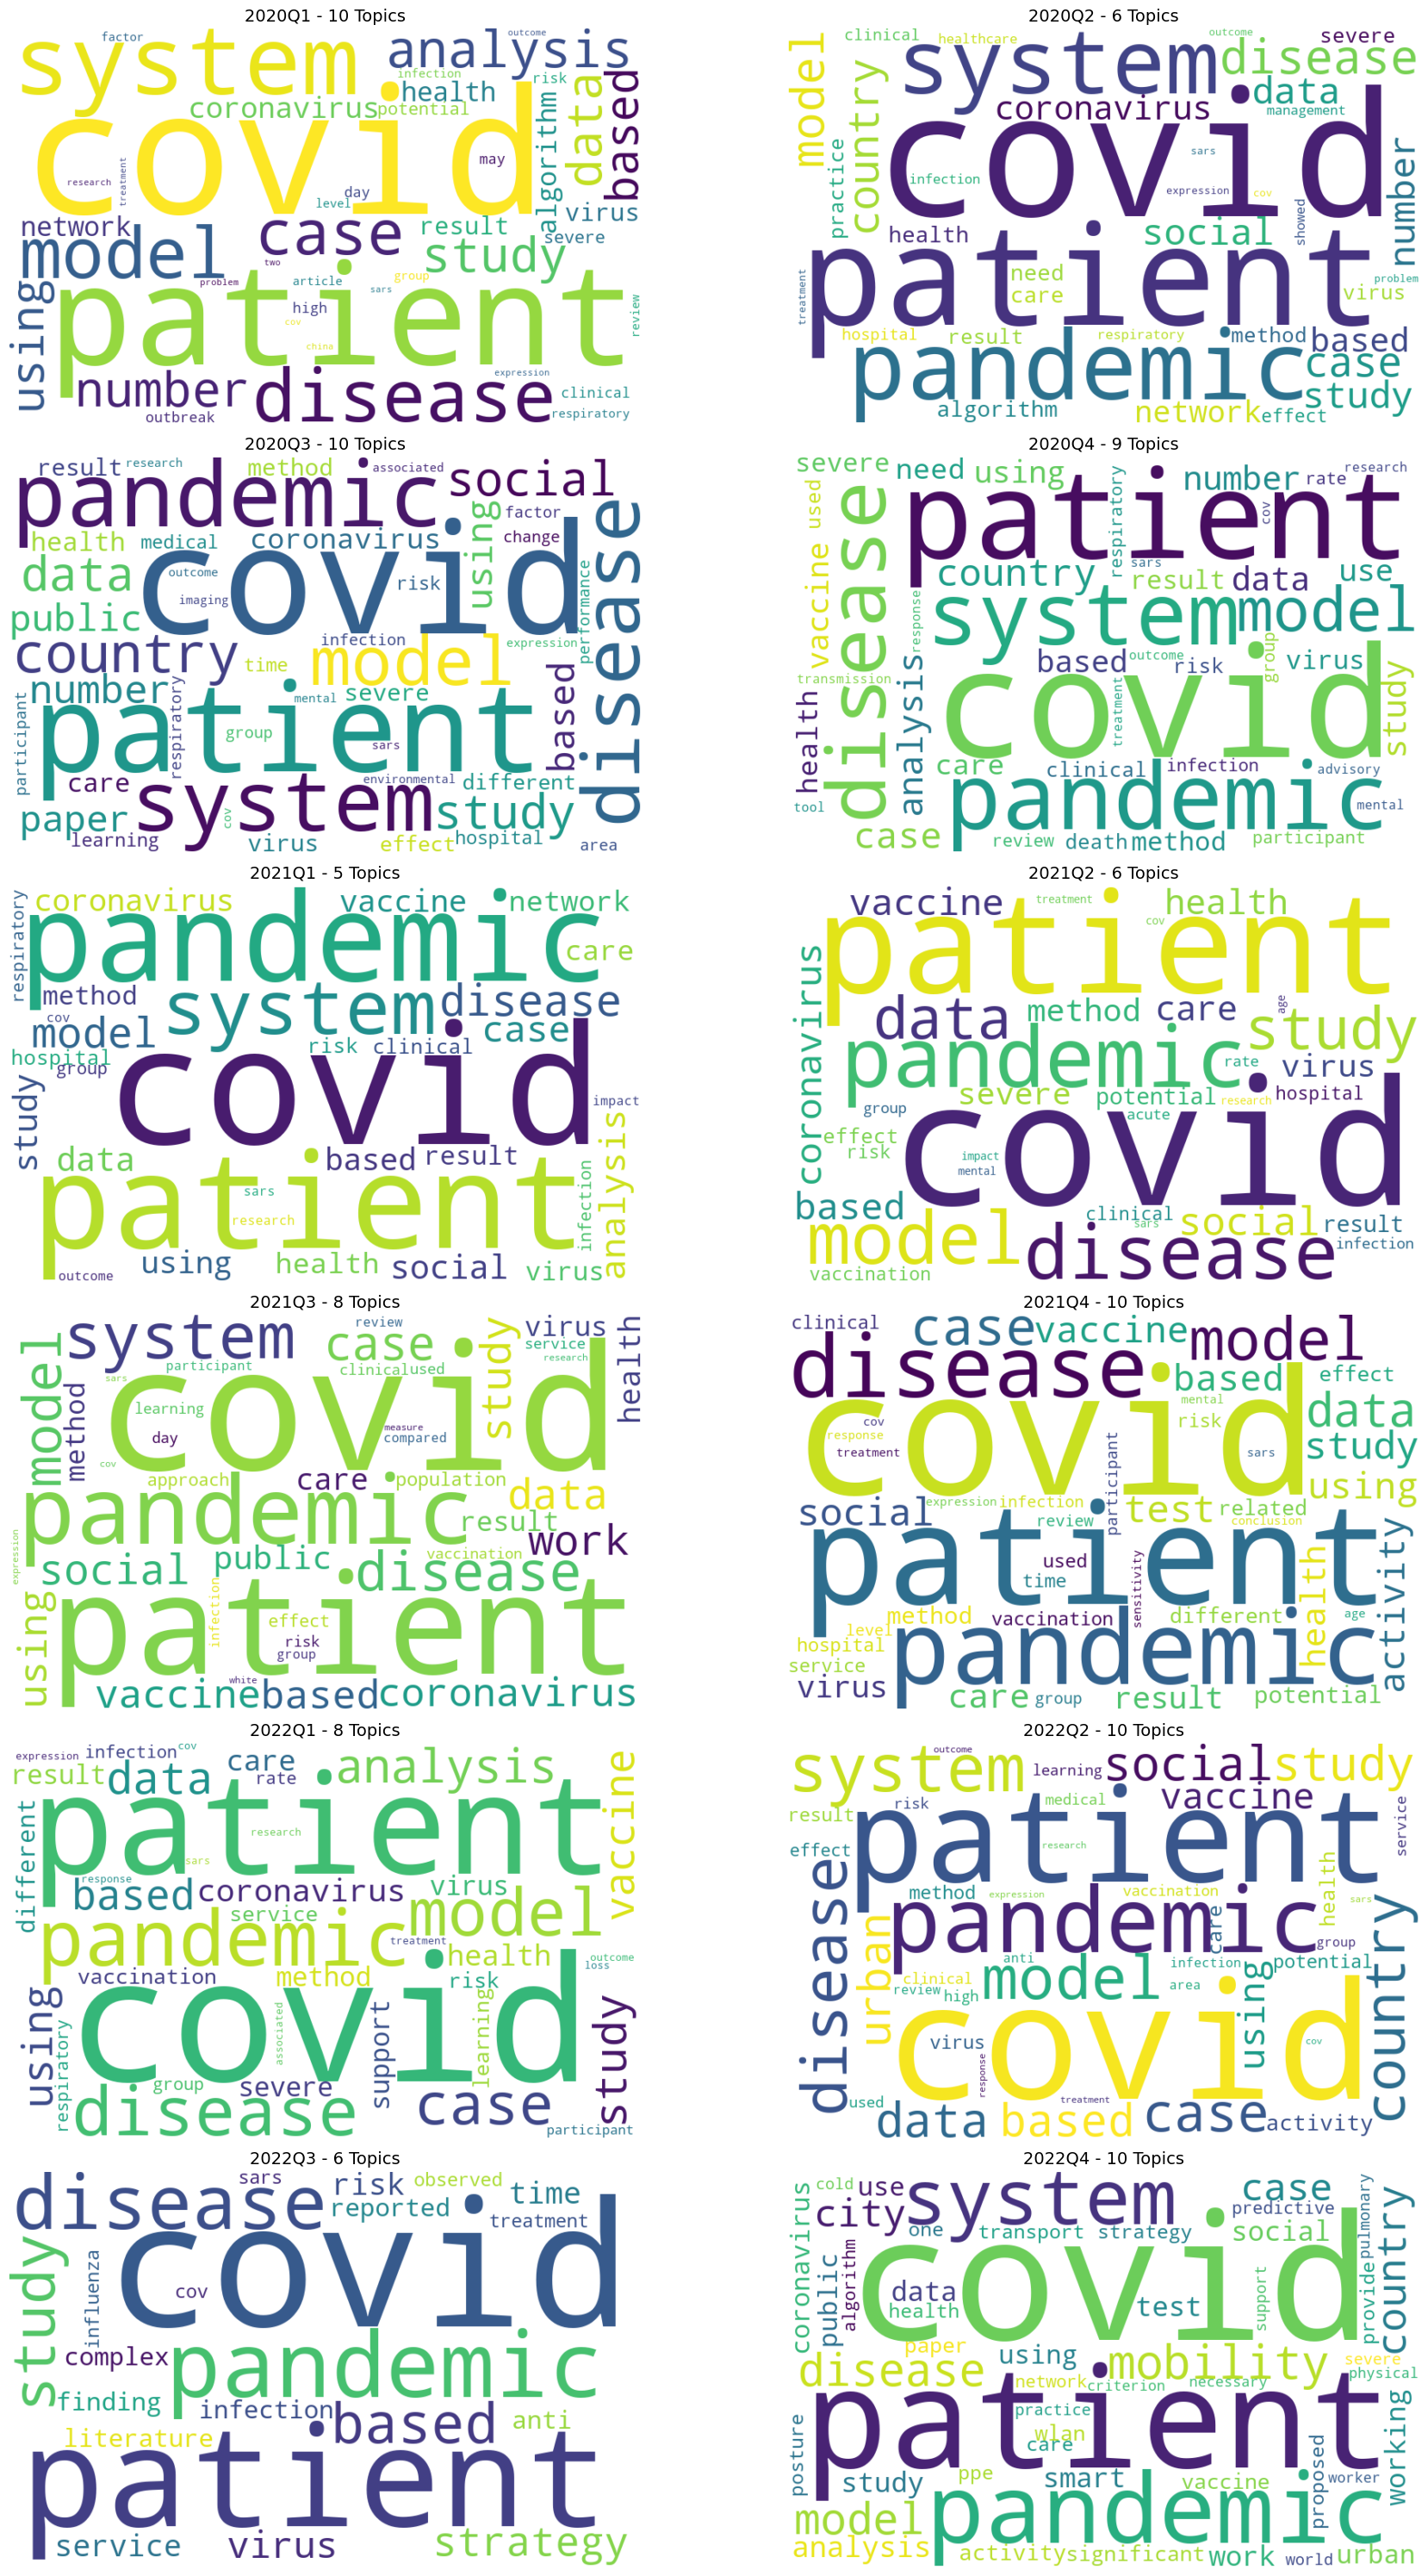

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# WordCloud Generation
def generate_matching_wordclouds(optimal_models, optimal_topic_numbers, dictionary):
    # Setting up figure
    num_periods = len(optimal_models)
    rows = (num_periods + 1) // 2
    plt.figure(figsize=(20, 5 * rows))
    
    for idx, (period, model) in enumerate(optimal_models.items()):
        # Collecting all words and their exact counts as shown the previous function: display_topics_with_counts
        word_freq = {}
        topic_count = optimal_topic_numbers[period]
        
        for i in range(topic_count):
            words = model.show_topic(i, topn=10)
            for word, prob in words:
                word_id = dictionary.token2id.get(word, -1)
                count = dictionary.cfs[word_id] if word_id != -1 else 0
                # Use the same weighting logic from display_topics_with_counts
                word_freq[word] = count  # Using the raw count to match the display function
        
        # Create subplot
        plt.subplot(rows, 2, idx+1)
        
        if word_freq:
            # Creating word clouds using the same counts
            wc = WordCloud(width=800, height=500,
                         background_color='white',
                         colormap='viridis',
                         max_words=50).generate_from_frequencies(word_freq)
            
            plt.imshow(wc, interpolation='bilinear')
            plt.title(f"{period} - {topic_count} Topics", fontsize=14)
            plt.axis('off')
            
            # Matching words to wordcloud image
            print(f"\n{period} - Same counts as displayed:")
            for i in range(topic_count):
                words = model.show_topic(i, topn=3)  # Show top 3 words per topic
                topic_words = []
                for word, prob in words:
                    word_id = dictionary.token2id.get(word, -1)
                    count = dictionary.cfs[word_id] if word_id != -1 else 0
                    topic_words.append(f"{word}({count})")
                print(f"Topic {i+1}: {', '.join(topic_words)}")
        else:
            plt.title(f"{period} - No Valid Words", fontsize=14)
            plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualizing the wordclouds
generate_matching_wordclouds(optimal_models, optimal_topic_numbers, dictionary)

In [ ]:
# Linechart Using "Magnet Words"

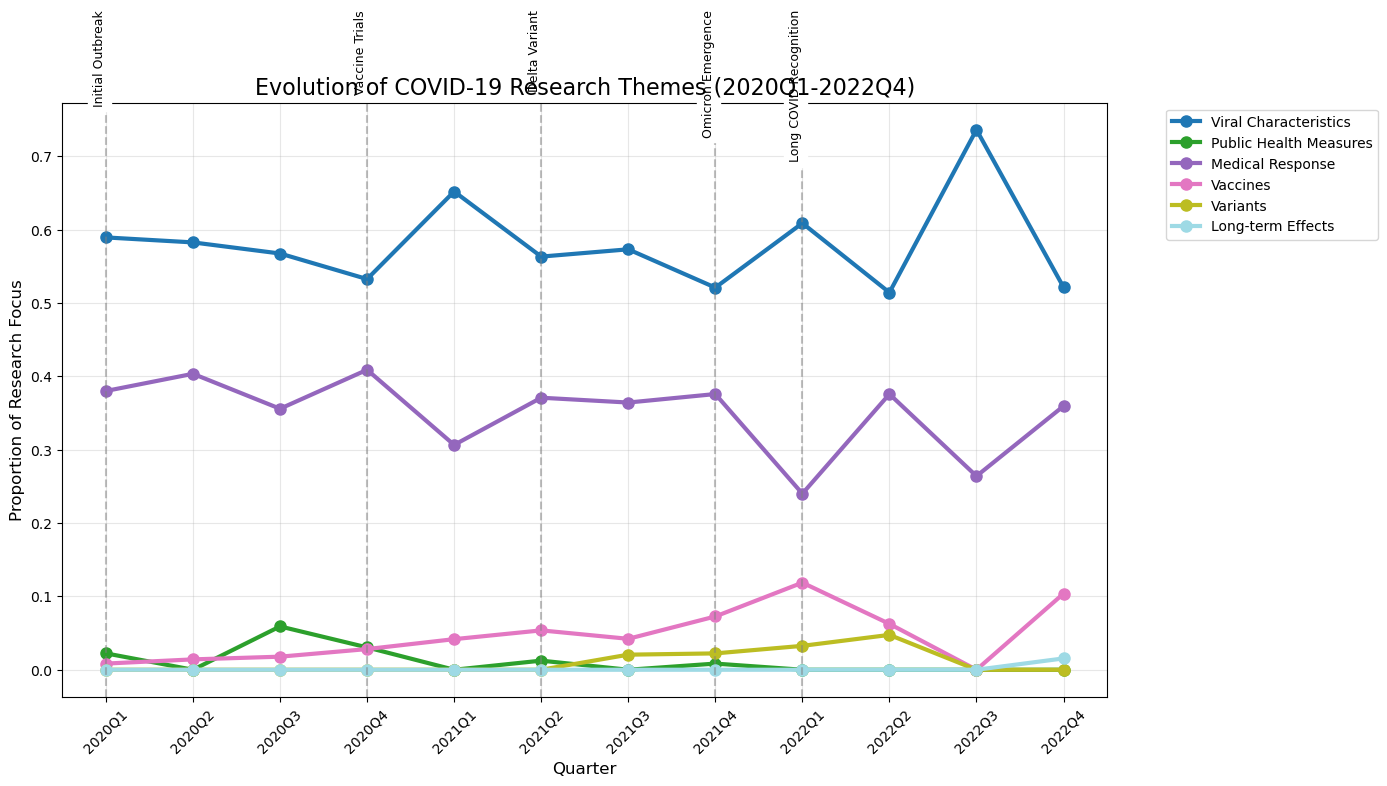

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Evolution of Popularity of Research Topics over time. (This uses hard-coded "Magnet words" for clustering, skip this function during code demo)
def plot_research_evolution(optimal_models, optimal_topic_numbers, dictionary):
    # Research themes and their keywords
    research_themes = {
        'Viral Characteristics': ['virus', 'sars', 'cov', 'coronavirus', 'spike protein', 'viral'],
        'Public Health Measures': ['lockdown', 'social distancing', 'mask', 'quarantine', 'non-pharmaceutical'],
        'Medical Response': ['patient', 'hospital', 'treatment', 'clinical', 'care'],
        'Vaccines': ['vaccine', 'mrna', 'pfizer', 'moderna', 'booster'],
        'Variants': ['variant', 'alpha', 'delta', 'omicron', 'ba.1', 'ba.2'],
        'Long-term Effects': ['long covid', 'post-acute', 'chronic', 'fatigue']
    }

    # Creating quarterly timeline
    quarters = pd.period_range('2020Q1', '2022Q4', freq='Q')
    theme_data = pd.DataFrame(index=quarters.astype(str))
    
    # Calculating theme prevalence per quarter
    for period in quarters:
        if period in optimal_models:
            model = optimal_models[period]
            
            for theme, keywords in research_themes.items():
                theme_score = 0
                # Search all topics
                for topic_id in range(optimal_topic_numbers[period]):
                    try:
                        topic_words = model.show_topic(topic_id, topn=25)
                    except:
                        topic_words = model.show_topic(topic_id, num_words=25)
                        
                    for word, weight in topic_words:
                        if any(kw in word.lower() for kw in keywords):
                            theme_score += weight
                theme_data.loc[str(period), theme] = theme_score
    
    # Normalize via total research output per quarter
    theme_data = theme_data.div(theme_data.sum(axis=1), axis=0)
    
    # Graphing evolution
    plt.figure(figsize=(14, 8))
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(research_themes)))
    
    for i, (theme, color) in enumerate(zip(research_themes.keys(), colors)):
        plt.plot(theme_data.index,
                theme_data[theme],
                label=theme,
                color=color,
                linewidth=3,
                marker='o',
                markersize=8)
    
    # Labels
    plt.title('Evolution of COVID-19 Research Themes (2020Q1-2022Q4)', fontsize=16)
    plt.xlabel('Quarter', fontsize=12)
    plt.ylabel('Proportion of Research Focus', fontsize=12)
    
    # Line up quarters in order
    plt.xticks(range(len(quarters)), [str(q) for q in quarters], rotation=45)
    plt.xlim(-0.5, len(quarters)-0.5)
    
    # Pandemic phase markers
    milestones = [
        ('Initial Outbreak', '2020Q1'),
        ('Vaccine Trials', '2020Q4'),
        ('Delta Variant', '2021Q2'),
        ('Omicron Emergence', '2021Q4'),
        ('Long COVID Recognition', '2022Q1')
    ]
    
    for label, quarter in milestones:
        if quarter in theme_data.index:
            x_pos = list(theme_data.index).index(quarter)
            plt.axvline(x=x_pos, color='gray', linestyle='--', alpha=0.5)
            plt.text(x_pos, 0.9, label, 
                   rotation=90, va='top', ha='right',
                   backgroundcolor='white',
                   fontsize=9)
    
    plt.grid(alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return theme_data

# Graph the plot
theme_evolution = plot_research_evolution(optimal_models, optimal_topic_numbers, dictionary)

In [ ]:
# The Flaws of Clustering Using Pure K-Means

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

# Function to display topics with counts and return the words for clustering (This is to demonstrate my learning process from k-means to (Sci)BERT. 
# Ignore for Code Demo)
def display_topics_with_counts(model, num_topics, dictionary=None):
    words_list = []
    
    for i in range(num_topics):
        words = model.show_topic(i, topn=10)
        print(f"Topic {i+1}: ", end="")
        
        # The list of words
        word_list = []
        for word, prob in words:
            if dictionary:  # If we have dictionary
                # Get word ID and global count from dictionary
                word_id = dictionary.token2id.get(word, -1)
                count = dictionary.cfs[word_id] if word_id != -1 else 0
                word_list.append(f"{word}({count})")
            else:
                word_list.append(word)
        
        print(", ".join(word_list))
        words_list.extend([word for word, _ in words])  # Collect words from all topics
    
    return words_list

# Function to cluster words using KMeans
def cluster_words(words_list, num_clusters=5):
    if len(words_list) < num_clusters:
        num_clusters = len(words_list)  # Ensure we don't have more clusters than words
    
    # Each word is treated as a separate "document" in TF-IDF
    words_text = words_list  # List of words, NOT a single string
    
    # TF-IDF Vectorizer to convert words into vector representations
    vectorizer = TfidfVectorizer(stop_words='english')
    X = vectorizer.fit_transform(words_text)
    
    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Get the clusters
    clusters = {i: [] for i in range(num_clusters)}
    for i, word in enumerate(words_list):
        cluster_id = kmeans.labels_[i]
        clusters[cluster_id].append(word)
    
    return clusters

# Example usage:
for period, model in optimal_models.items():
    print(f"\n{period} - Optimal Number of Topics: {optimal_topic_numbers[period]}")
    
    # Get all words from the display_topics_with_counts function
    words_list = display_topics_with_counts(
        model, 
        optimal_topic_numbers[period],
        dictionary=dictionary  # Your Gensim dictionary
    )
    
    # Cluster extracted words
    clusters = cluster_words(words_list)
    
    # Print all clusters
    print("\nClusters of words:")
    for cluster_id, words in clusters.items():
        print(f"Cluster {cluster_id + 1}: {', '.join(words)}")



2020Q1 - Optimal Number of Topics: 10
Topic 1: result(5), based(7), model(13), network(6), problem(1), analysis(9), study(8), algorithm(6), system(16), using(7)
Topic 2: study(8), intervention(0), review(2), outcome(1), patient(21), trial(0), group(2), result(5), research(1), clinical(3)
Topic 3: cell(0), protein(0), level(2), model(13), ace(0), system(16), virus(5), expression(1), receptor(0), potential(5)
Topic 4: covid(35), disease(14), cov(1), sars(1), coronavirus(7), infection(2), case(10), virus(5), health(6), respiratory(2)
Topic 5: patient(21), study(8), health(6), year(0), high(3), risk(3), result(5), trauma(0), using(7), breathing(0)
Topic 6: infection(2), virus(5), study(8), human(0), bat(0), result(5), protein(0), dog(0), factor(2), pcr(0)
Topic 7: patient(21), covid(35), day(3), study(8), clinical(3), severe(5), result(5), cov(1), infection(2), sars(1)
Topic 8: case(10), patient(21), clinical(3), covid(35), treatment(1), cov(1), sars(1), drug(0), article(2), result(5)
Top

In [ ]:
# Significance of Covid Variants in the Dataset

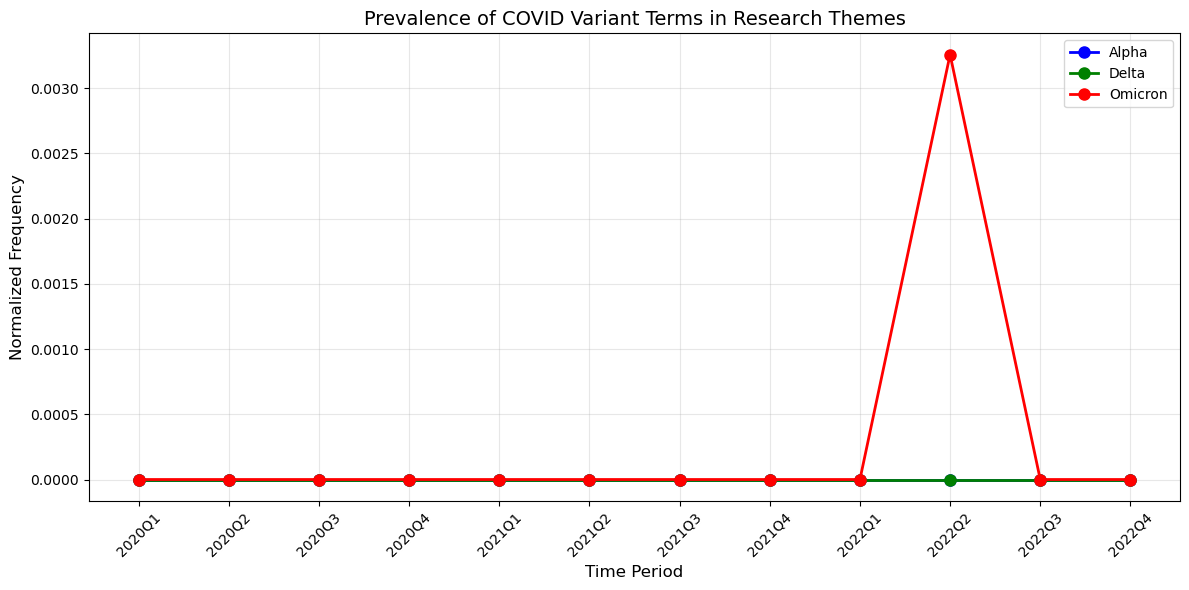

,alpha,delta,omicron
2020Q1,0.0,0.0,0.0
2020Q2,0.0,0.0,0.0
2020Q3,0.0,0.0,0.0
2020Q4,0.0,0.0,0.0
2021Q1,0.0,0.0,0.0
2021Q2,0.0,0.0,0.0
2021Q3,0.0,0.0,0.0
2021Q4,0.0,0.0,0.0
2022Q1,0.0,0.0,0.0
2022Q2,0.0,0.0,0.003257


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Graph plot that displays the prevalance of articles discussing Coronavirus variants between 2020Q1 and 2022Q4.
def plot_variant_prevalence(optimal_models, optimal_topic_numbers):
    # keywords to track
    variants = {
        'alpha': ['alpha', 'b.1.1.7'],
        'delta': ['delta', 'b.1.617.2'], 
        'omicron': ['omicron', 'ba.1', 'ba.2', 'bq.1']
    }
    
    # Prep data structure
    periods = sorted(optimal_models.keys())
    variant_data = pd.DataFrame(index=periods, columns=variants.keys())
    
    # Count variants mentions per quarter
    for period in periods:
        model = optimal_models[period]
        total_words = 0
        counts = defaultdict(int)
        
        for topic_id in range(optimal_topic_numbers[period]):
            try:
                # Get top words
                try:
                    topic_words = model.show_topic(topic_id, topn=20)
                except:
                    topic_words = model.show_topic(topic_id, num_words=20)
                
                # Count # of variant mentions
                for word, weight in topic_words:
                    word_lower = word.lower()
                    for variant, keywords in variants.items():
                        if any(kw in word_lower for kw in keywords):
                            counts[variant] += weight
                    total_words += weight
                    
            except Exception as e:
                print(f"Error processing topic {topic_id} in {period}: {str(e)}")
                continue
        
        # Normalize counts
        for variant in variants:
            variant_data.at[period, variant] = counts[variant] / total_words if total_words > 0 else 0
    
    # Creating the line chart
    plt.figure(figsize=(12, 6))
    
    # Ploting each variant's prevalence
    colors = {'alpha': 'blue', 'delta': 'green', 'omicron': 'red'}
    for variant in variants:
        plt.plot(variant_data.index.astype(str), 
                variant_data[variant],
                label=variant.capitalize(),
                color=colors[variant],
                marker='o',
                linewidth=2,
                markersize=8)
    
    # Format of the Chart
    plt.title('Prevalence of COVID Variant Terms in Research Themes', fontsize=14)
    plt.xlabel('Time Period', fontsize=12)
    plt.ylabel('Normalized Frequency', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # 5. Add important pandemic milestones
    milestones = {
        'Alpha\nidentified': '2020-11',
        'Delta\nemergence': '2021-05', 
        'Omicron\ndetected': '2021-11'
    }
    
    for label, date in milestones.items():
        if date in variant_data.index.astype(str):
            plt.axvline(x=date, color='gray', linestyle='--', alpha=0.5)
            plt.text(date, plt.ylim()[1]*0.9, label, 
                    ha='center', va='top',
                    backgroundcolor='white')
    
    plt.tight_layout()
    plt.show()
    
    return variant_data

# The visualization
variant_prevalence = plot_variant_prevalence(optimal_models, optimal_topic_numbers)
display(variant_prevalence)

# Training and Displaying LDA Topic Model

In [26]:
# We calculate an average or use the most frequent optimal_topic_number:
average_optimal_topics = int(np.mean(list(optimal_topic_numbers.values())))
# Retrain LDA on the entire dataset with the optimal number of topics using sklearn's LDA for better handling of TF-IDF
lda = LatentDirichletAllocation(
    n_components=average_optimal_topics,
    random_state=42,
    learning_method='online'
)
lda.fit(tfidf_matrix)

# Function to display the top words in each topic
def display_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        # Get top words without duplicates
        top_words = []
        seen_words = set()
        
        # Iterate through words in order of importance
        for i in topic.argsort()[::-1]:
            word = feature_names[i]
            if word not in seen_words and len(word) > 2:
                seen_words.add(word)
                top_words.append(word)
                if len(top_words) == n_top_words:
                    break
        
        # Print formatted output
        print(f"Topic {topic_idx + 1}:")
        print("   • " + "\n   • ".join(top_words))
        print()  # Extra space between topics

# Display topics
feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(lda, feature_names)

Topic 1:
   • student
   • learning
   • education
   • teaching
   • hcws
   • cancer
   • medical
   • online
   • virtual
   • opioid

Topic 2:
   • covid
   • health
   • pandemic
   • data
   • model
   • social
   • research
   • country
   • study
   • public

Topic 3:
   • care
   • patient
   • pandemic
   • covid
   • surgery
   • healthcare
   • service
   • surgical
   • hospital
   • nurse

Topic 4:
   • patient
   • covid
   • case
   • disease
   • infection
   • mortality
   • risk
   • clinical
   • day
   • severe

Topic 5:
   • vaccine
   • vaccination
   • systematic
   • systematic review
   • review
   • covid vaccine
   • meta
   • meta analysis
   • covid vaccination
   • mrna

Topic 6:
   • mental
   • anxiety
   • mental health
   • health
   • child
   • participant
   • depression
   • study
   • stress
   • adult

Topic 7:
   • learning
   • image
   • model
   • pregnant
   • machine
   • pregnancy
   • deep
   • machine learning
   • woman
   • algorithm


# Analyzing and Summarizing Topic Dominance

In [28]:
# Transform the documents to topic distribution
topic_distributions = lda.transform(tfidf_matrix)
df_subset['dominant_topic'] = np.argmax(topic_distributions, axis=1) + 1 

# Count papers per topic
topic_counts = df_subset['dominant_topic'].value_counts().sort_index()
print("Papers per topic:")
for topic_number, count in topic_counts.items():
    print(f"Topic {topic_number}: {count} papers")

Papers per topic:
Topic 1: 19 papers
Topic 2: 20426 papers
Topic 3: 1832 papers
Topic 4: 11163 papers
Topic 5: 183 papers
Topic 6: 3387 papers
Topic 7: 433 papers
Topic 8: 12557 papers


# Visualizing Topic Trends Over Time

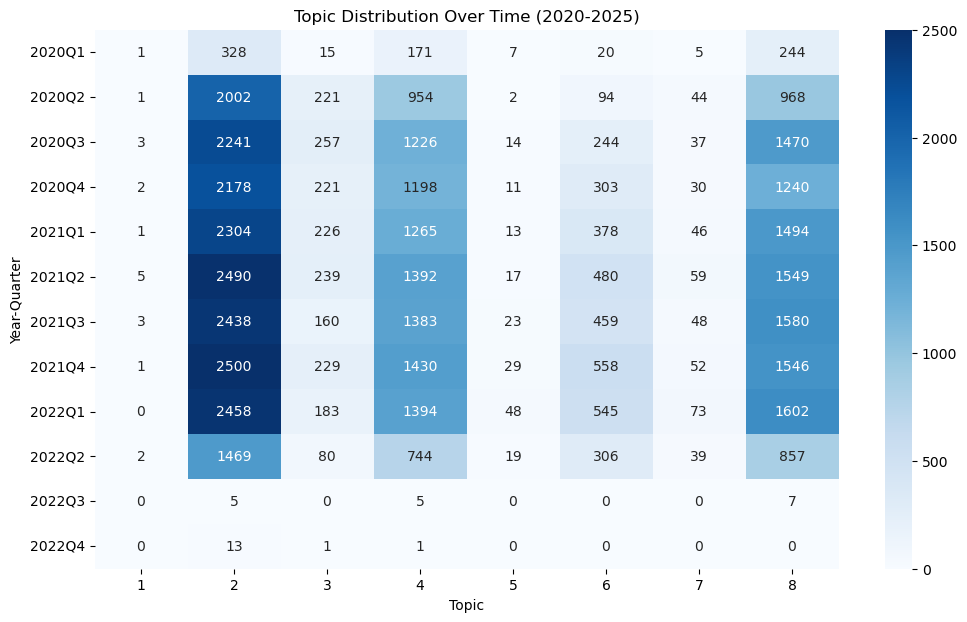

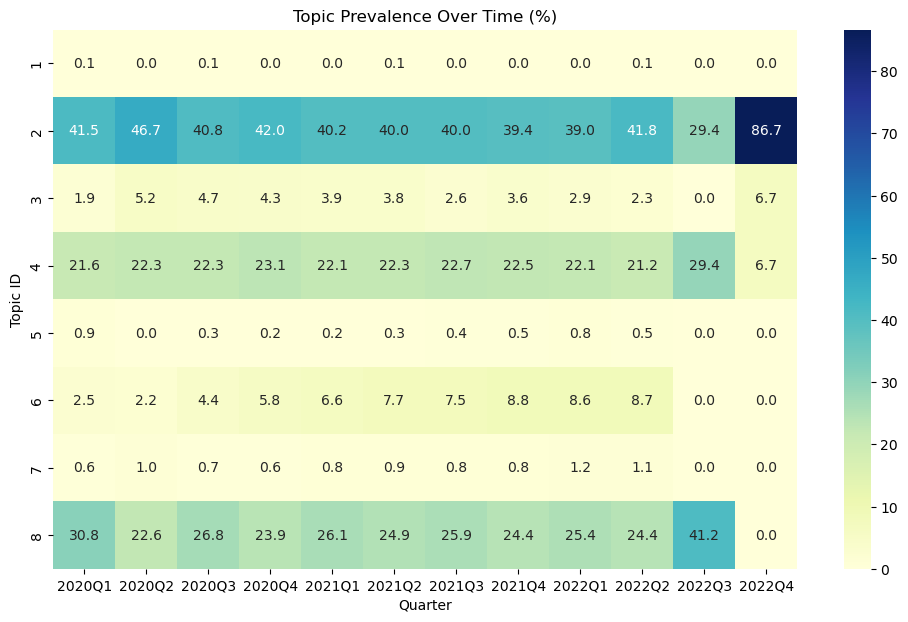

Sample of DataFrame with topic assignments:
                                                    title year_quarter  \
889956  Real-world deployment of lateral flow SARS-CoV...       2021Q4   
716810  Improving Oxygen Capacity at ITBP Referral Hos...       2021Q4   
53129   Clinician-Focused Overview and Developments in...       2020Q4   
142042  The effectiveness of trauma care systems at di...       2021Q3   
942810  Development of ultrahigh‐performance liquid ch...       2020Q2   

        dominant_topic  
889956               4  
716810               2  
53129                2  
142042               4  
942810               8  


In [30]:
# Group by quarter and topic
topic_trends = df_subset.groupby(['year_quarter', 'dominant_topic']).size().unstack(fill_value=0)

# Normalize to percentages
topic_percentages = topic_trends.div(topic_trends.sum(axis=1), axis=0) * 100

# Plot the raw count heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(topic_trends, annot=True, cmap="Blues", fmt="g", cbar=True)
plt.title("Topic Distribution Over Time (2020-2025)")
plt.xlabel("Topic")
plt.ylabel("Year-Quarter")
plt.show()

# Plot the percentage heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(topic_percentages.T, cmap="YlGnBu", annot=True, fmt=".1f")
plt.title("Topic Prevalence Over Time (%)")
plt.xlabel("Quarter")
plt.ylabel("Topic ID")
plt.show()

print("Sample of DataFrame with topic assignments:")
print(df_subset[['title', 'year_quarter', 'dominant_topic']].head())

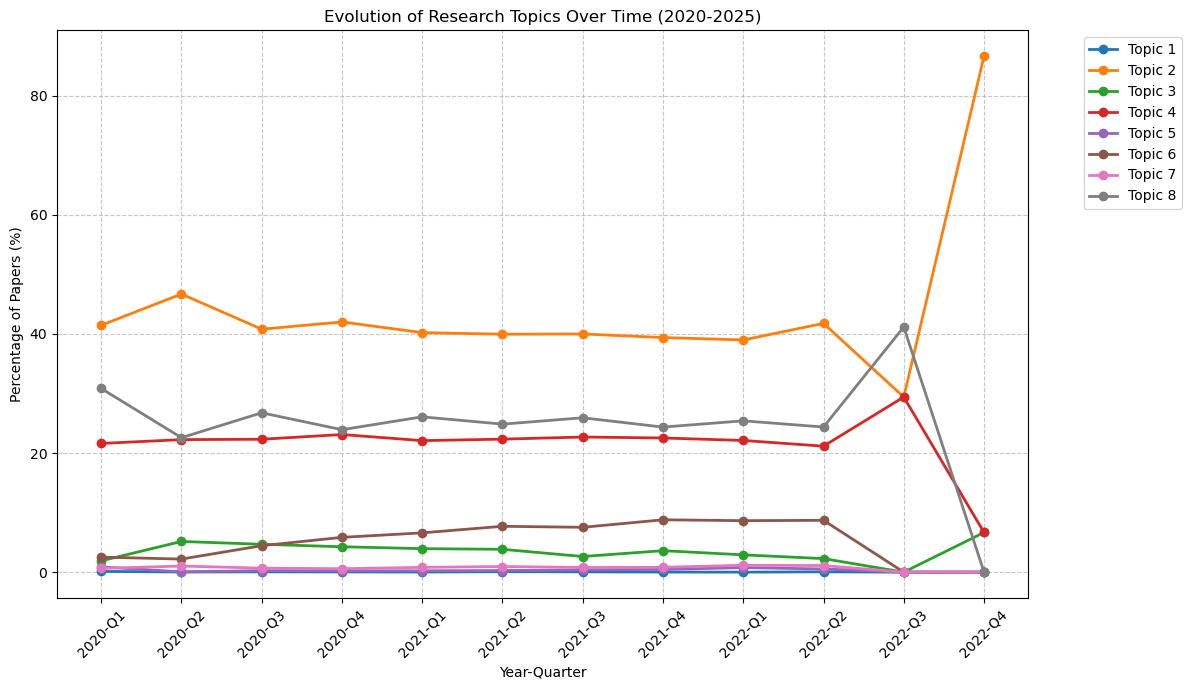

In [42]:
# Convert Period index to strings in "YYYY-QQ" format for the x-axis
x_labels = [f"{period.year}-Q{period.quarter}" for period in topic_percentages.index]
x_values = range(len(x_labels))  # using numeric positions for plotting

plt.figure(figsize=(12, 7))
for topic in topic_percentages.columns:
    plt.plot(x_values, topic_percentages[topic], 
             marker='o', label=f'Topic {topic}', linewidth=2)

plt.title('Evolution of Research Topics Over Time (2020-2025)')
plt.xlabel('Year-Quarter')
plt.ylabel('Percentage of Papers (%)')
plt.xticks(x_values, x_labels, rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()